# Credit card fraud detection

## Introduction

The machine learning project aims to detect fraudulent credit card transaction, which is a growing problem for the banking industry and also for consumers. Due to growing scam and social engineering activities more people are victims. Therefore there are multiple stakeholders (regulatory authorities (in europe: EBA & ECB), banks, consumers) interested in a sufficient fraud prevention and detection. 



The project is a classification problem, with highly unbalanced proportions of our to explainable variable y (is_fraud). Classifing the transaction into fraudulent transaction, while actually being fraudulent transaction is crucial for the credit card originating bank. Not detecting fraudulent transaction leads to financial liability damages, binding workers recourses and also damaging the reputation of the bank as safe financial service provider. Marked false positive transactions are also a problem for the bank business. Getting warning messages to the client or even blocking the credit card results into less card activity and therefore less revenue and profit for the bank. In the worst case clients will even terminate their credit card contract, because the credit card is not reliable when it should be. The declined using of a (business) credit card, for a late hotel check in, is horrible and for sure not a nice experience in a tight working schedule.    


The credit card data (most likely synthetic data) is downloaded from Hugging face (https://huggingface.co/datasets/pointe77/credit-card-transaction), without providing any descriptions.Nevertheless the used variables are quit obvious, by their structure and their content. So the qualitative data description will be conducted on industrial experience and best guesses.


The Script CC_Fraud_DATA_Prep.ipynb already creates via feature engineering variables from the initial dataset which is based on the initial Hugging Face dataset and the FBI Crime Data. To make this script cleaner this script starts, with the used dataset description and then provides the model usage.  

## General steps in this Project
As first step the dataset is changed and enriched with constructed variables (feature engineering) to get a better explanibility for classification fraud, whereas is_fraud=1 is a fraudulent transaction. The steps of constructing variables are seperated in the script (CC_Fraud_Data_Prep.ipynb). A descriptive analysis of the constructed and original dataset is conducted, by using basic descriptive statistics and some visualisations. Since the dataset is not just a simple cross sectional dataset, not considering any time dependet relations could be fatally missing any crucial trends. A short time series analysis of our dataset is therefore included.

The feature enigineering of variables leads in multiple variables which are highly correlated to each other (by being based on the same features), since it is a Tree based algorithm, this issue is not adressed as it would be if we also contained the lasso regression and linear support vector machine. Nevertheless the project contains LightGBM for the purpose of deciding and selecting variables, which variables more efficiently leads to a better explanibilty. 

Both procedures are included, to get a more decisive analysis of the variable, whereas the lasso regression investigates linear relationship it provides negative or positive links to our fraud marker (y), which is a valuable information for the bank and future steps in avoiding fraud.  


In [1]:
# Importing standard packages
import polars as pl # Faster then pandas, 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt # visualization
#import sklearn as 

from geopy.distance import distance #, geodesic, great_circle # Feature Engineering module for Geodata

In [2]:
# reading in the datasets

cc_train =  pl.read_parquet("credit_card_trans_train.parquet")
cc_test  = pl.read_parquet("credit_card_trans_test.parquet")
# cc_comb = pl.concat([cc_train, cc_test])
# del(cc_train, cc_test)
ID_cols = ['Owner_ID', 'cc_num', 'trans_num','trans_date_trans_time','merchant', 'dist_client_merchant']
cc_train_ID = cc_train.select(ID_cols)
cc_test_ID = cc_test.select(ID_cols)

cc_train = cc_train.drop(['Owner_ID', 'cc_num','trans_date_trans_time','merchant', 'dist_client_merchant'])
cc_test = cc_test.drop(['Owner_ID', 'cc_num','trans_date_trans_time','merchant', 'dist_client_merchant'])


In [3]:
cc = cc_train
# Trans_num as ID and seperate Information DataFrame 
# To make the Data_Frame nicer to handle all Identifier variables and some string variables are seperated from the dataset:
#  
"""
cc_ID = 
print(f"Columns: {cc.columns.drop('')}")
"""
cc.head(5)


trans_num,category,amt,gender,city_pop,job,is_fraud,State_Risk_Rating,trans_date,trans_time_diff,travel_time_km,daily_trans,daily_trans_lagged,net_binary,Population_Density,birth_year,generation,net_binary_comb_travel_time,net_binary_comb_trans_time
str,str,f64,str,i64,str,i64,i64,date,f64,f64,u32,u32,i32,str,i32,str,f64,f64
"""98e3dcf98101146a577f85a34e58fe…","""misc_net""",38.731176,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-01,0.0,0.0,1,0,0,"""Village""",1986,"""Millennials""",0.0,0.0
"""498120fc45d277f7c88e3dba79c338…","""gas_transport""",205.568402,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,71862.0,0.003126,4,0,1,"""Village""",1986,"""Millennials""",0.003126,71862.0
"""95f514bb993151347c7acdf8505c3d…","""gas_transport""",86.873989,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,159.0,0.661115,4,4,1,"""Village""",1986,"""Millennials""",0.661115,159.0
"""4f0c1a14e0aa7eb56a490780ef9268…","""kids_pets""",78.630423,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,13838.0,0.006367,4,4,1,"""Village""",1986,"""Millennials""",0.006367,13838.0
"""3b2ebd3af508afba959640893e1e82…","""home""",65.831735,"""F""",1645,"""Information systems manager""",0,2353556,2019-01-02,1952.0,0.068047,4,4,1,"""Village""",1986,"""Millennials""",0.068047,1952.0


### A Short general description of the dataset and the difference to the original dataset.

The first variables contain Keyident data on different levels. We originated an unique OwnerID instead of the name, a CC_num (Credit Card Number) and trans_num (Transaction number) already existed, to identify fraudulent transaction and the related owner and card. The training data ends at the threshold in noon (2020, 6, 21), starting from (2019, 1, 1) therefore including 18 months. Comparing to the consecutive half year period in the test dataset.
The original dataset contains location data which is partly written as string dtype and also in latitude and longitude of customer and also merchant data. Since we derived in the feature engineering script the following variables -> The Variables: street	city	state	zip	lat	long merch_lat	merch_long merch_zipcode are deleted. 
The transaction date information is used to derive daily and weekly timestamps and based on these timestamps and location data features are derived.
Since we got time series data, in comparison to cross sectional data, it would be fatal to calculate outliers, based on information which are in the future and including them into the row of a past transaction. First attempts ignoring this, have lead to biased results. 


## First Overview of the Data

### Qualitative Description of the DATA, What the Variables mean.



In [4]:
# Since we got labeled data we can check the Time Series of fraud activity (at least for this data, the reality might be different with unlabeled data):
cc = cc_train
min_date = cc['trans_date'].min()

# weeks since start as X Index
cc = cc.with_columns(
    ((pl.col('trans_date') - min_date).dt.total_days() / 7).floor().cast(pl.Int32).alias('week_index')
)
# Aggregation weekly data
weekly_stats = cc.group_by(['week_index']).agg([
    pl.len().alias('total_transactions'),
    pl.col('is_fraud').sum().alias('fraud_count'),
    (pl.col('is_fraud').sum() / pl.len() * 100).alias('fraud_percentage')
]).sort(['week_index'])


trans_num,category,amt,gender,city_pop,job,is_fraud,State_Risk_Rating,trans_time_diff,travel_time_km,daily_trans,daily_trans_lagged,net_binary,Population_Density,birth_year,generation,net_binary_comb_travel_time,net_binary_comb_trans_time
str,str,f64,str,i64,str,i64,i64,f64,f64,u32,u32,i32,str,i32,str,f64,f64
"""98e3dcf98101146a577f85a34e58fe…","""misc_net""",38.731176,"""F""",1645,"""Information systems manager""",0,2353556,0.0,0.0,1,0,0,"""Village""",1986,"""Millennials""",0.0,0.0
"""498120fc45d277f7c88e3dba79c338…","""gas_transport""",205.568402,"""F""",1645,"""Information systems manager""",0,2353556,71862.0,0.003126,4,0,1,"""Village""",1986,"""Millennials""",0.003126,71862.0
"""95f514bb993151347c7acdf8505c3d…","""gas_transport""",86.873989,"""F""",1645,"""Information systems manager""",0,2353556,159.0,0.661115,4,4,1,"""Village""",1986,"""Millennials""",0.661115,159.0
"""4f0c1a14e0aa7eb56a490780ef9268…","""kids_pets""",78.630423,"""F""",1645,"""Information systems manager""",0,2353556,13838.0,0.006367,4,4,1,"""Village""",1986,"""Millennials""",0.006367,13838.0
"""3b2ebd3af508afba959640893e1e82…","""home""",65.831735,"""F""",1645,"""Information systems manager""",0,2353556,1952.0,0.068047,4,4,1,"""Village""",1986,"""Millennials""",0.068047,1952.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""ad7dfdf0aaa36cd7985dd1f35ca0e2…","""personal_care""",391.859479,"""M""",532,"""Audiological scientist""",0,2675478,30740.0,0.002344,4,4,1,"""Village""",1956,"""Boomer""",0.002344,30740.0
"""6d427d735c9f9b2fd480f2c24b6525…","""gas_transport""",541.232555,"""M""",532,"""Audiological scientist""",0,2675478,12962.0,0.003872,4,0,1,"""Village""",1956,"""Boomer""",0.003872,12962.0
"""9814049bcc69fb31d81f4a907f2fe2…","""shopping_net""",1354.000769,"""M""",532,"""Audiological scientist""",0,2675478,7618.0,0.012379,4,4,0,"""Village""",1956,"""Boomer""",0.0,0.0


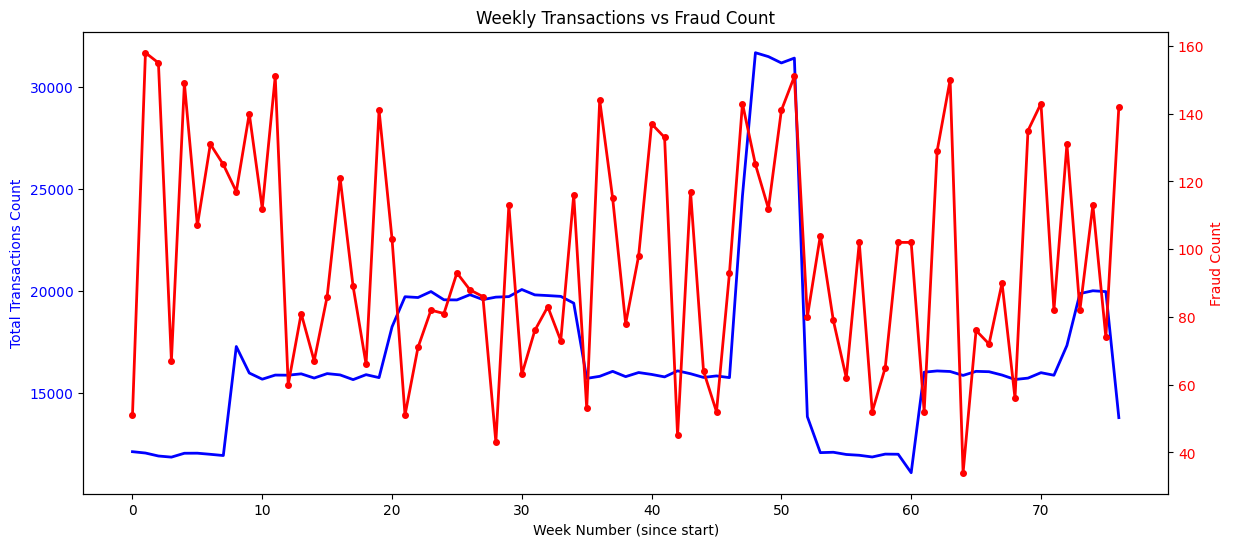

In [5]:
# Plot using week_index
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(weekly_stats['week_index'], weekly_stats['total_transactions'], 
         label='Total Transactions', color='blue', linewidth=2)
ax1.set_xlabel('Week Number (since start)')
ax1.set_ylabel('Total Transactions Count', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx()
ax2.plot(weekly_stats['week_index'], weekly_stats['fraud_count'], 
         label='Fraud Count', color='red', linewidth=2, marker='o', markersize=4)
ax2.set_ylabel('Fraud Count', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Weekly Transactions vs Fraud Count')

cc.drop(['trans_date','week_index'])

Checking the Time Series visualy, the following seems to apply:
- The fraud count seems to be stationary. 
- No seasonality we can model (no weekly, monthly patterns). The CC usage seems to get some seasonality, unfortunately the data does not cover multiple years (annualy seasonality seems to be dominating) and therefore it might be unsufficient to feature engineer. (The rise of CC usage for christmas and then the low account balance afterwards is clearly visable. )
- No strong trend (fraud isn't systematically increasing or decreasing)
- Most likely no memory effect (past fraud doesn't predict future fraud)

## Variables to include into our further tests:


Variable description of included variables:
- Merchant category of his invoice originitation business [category]
- Amount of the credit card transaction [amt]

Variable description of the constructed variables:
- State Risk Rating calculated via losses per 100,000 citizens in each us-state [State_Risk_Rating] 
- Transaction time difference per credit card [trans_time_diff] 
- Travel Distance in km per second, calculated by using the transaction time per credit card in relation to the distance of the last transaction place [travel_time_km] 
- Number of daily transactions, since no future information is allowed, only the transaction numbers of the last day are included [daily_trans_lagged] 
- Binary variable if the merchant category is as online store assumed [net_binary]
- Density classficiation of the clients address [Population_Density]
- Birth year of the client considering his date of birth [birth_year]
- Combined variable as product of net binary and travel time between transactions [net_binary_comb_travel_time]
- Combined variable as product of net binary and transaction time [net_binary_comb_trans_time]


## Basic Statistical Analysis

First, we look at descriptive statistics in a table. For categorical variables, we use different table metrics, then include some graphs.

In [6]:
def stat_values(df: pl.DataFrame, numeric_vars: list) -> pl.DataFrame:
    
    stats_list = []
    for col in numeric_vars: 
        stats = {
            "variable": col,
            "mean": df[col].mean(),
            "median": df[col].median(),
            "std": df[col].std(),
            "variance": df[col].var(),
            "min": df[col].min(),
            "q1": df[col].quantile(0.25),
            "q3": df[col].quantile(0.75),
            "max": df[col].max(),
            "range": df[col].max() - df[col].min(),
            "iqr": df[col].quantile(0.75) - df[col].quantile(0.25),
            "skewness": df[col].skew(),
            "kurtosis": df[col].kurtosis(),
        }
        stats_list.append(stats)
    
    return pl.DataFrame(stats_list)

# Usage
stats_df = stat_values(cc, ['amt','trans_time_diff','travel_time_km','daily_trans_lagged'])
stats_df

variable,mean,median,std,variance,min,q1,q3,max,range,iqr,skewness,kurtosis
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""amt""",334.319946,160.379315,885.781299,784608.510401,0.517053,41.957776,402.85626,230381.576532,230381.059479,360.898484,56.166337,8936.094469
"""trans_time_diff""",32460.388633,16536.0,47391.441671,2.2459e9,0.0,5996.0,40195.0,1.341471e6,1.341471e6,34199.0,4.278666,31.993842
"""travel_time_km""",0.052506,0.005553,1.054583,1.112146,0.0,0.002106,0.016307,216.754079,216.754079,0.014201,95.150222,12235.421253
"""daily_trans_lagged""",3.998114,4.0,3.769509,14.209199,0.0,0.0,6.0,34.0,34.0,6.0,1.028664,1.571834


In [7]:
def categorical_stats(df: pl.DataFrame, categorical_vars: list) -> pl.DataFrame:
    
    stats_list = []
    for col in categorical_vars:
        
        value_counts = df[col].value_counts()
                
        most_frequent = value_counts[0, col]
        most_freq_count = value_counts[0, "count"] 
        
        stats = {
            "variable": col,
            "n_unique": df[col].n_unique(),
            "most_frequent": most_frequent,
            "most_freq_pct": (most_freq_count / df.height) * 100,
        }
        stats_list.append(stats)
    return pl.DataFrame(stats_list)

cat_stats = categorical_stats(cc, ['category','State_Risk_Rating','Population_Density','gender'])#,'job'])#,'generation'])
cat_stats

variable,n_unique,most_frequent,most_freq_pct
str,i64,str,f64
"""category""",14,"""kids_pets""",8.717296
"""State_Risk_Rating""",51,"""2134317""",1.265313
"""Population_Density""",5,"""Town""",13.647599
"""gender""",2,"""F""",54.744867


## Some graphical visualisation of the distributions

In [8]:
X = cc[['amt',
 'gender',
 'trans_time_diff',
 'travel_time_km',
 'daily_trans_lagged',
 'net_binary_comb_travel_time',
 'net_binary_comb_trans_time',
 'birth_year',
 #'weekly_transactions',
 'net_binary',
# 'Amount_Outlier_bin',
 'State_Risk_Rating',
 'Population_Density']].to_pandas()

y = cc['is_fraud'].to_numpy()

<positron-console-cell-9>:16: UserWarning: To output multiple subplots, the figure containing the passed axes is being cleared.


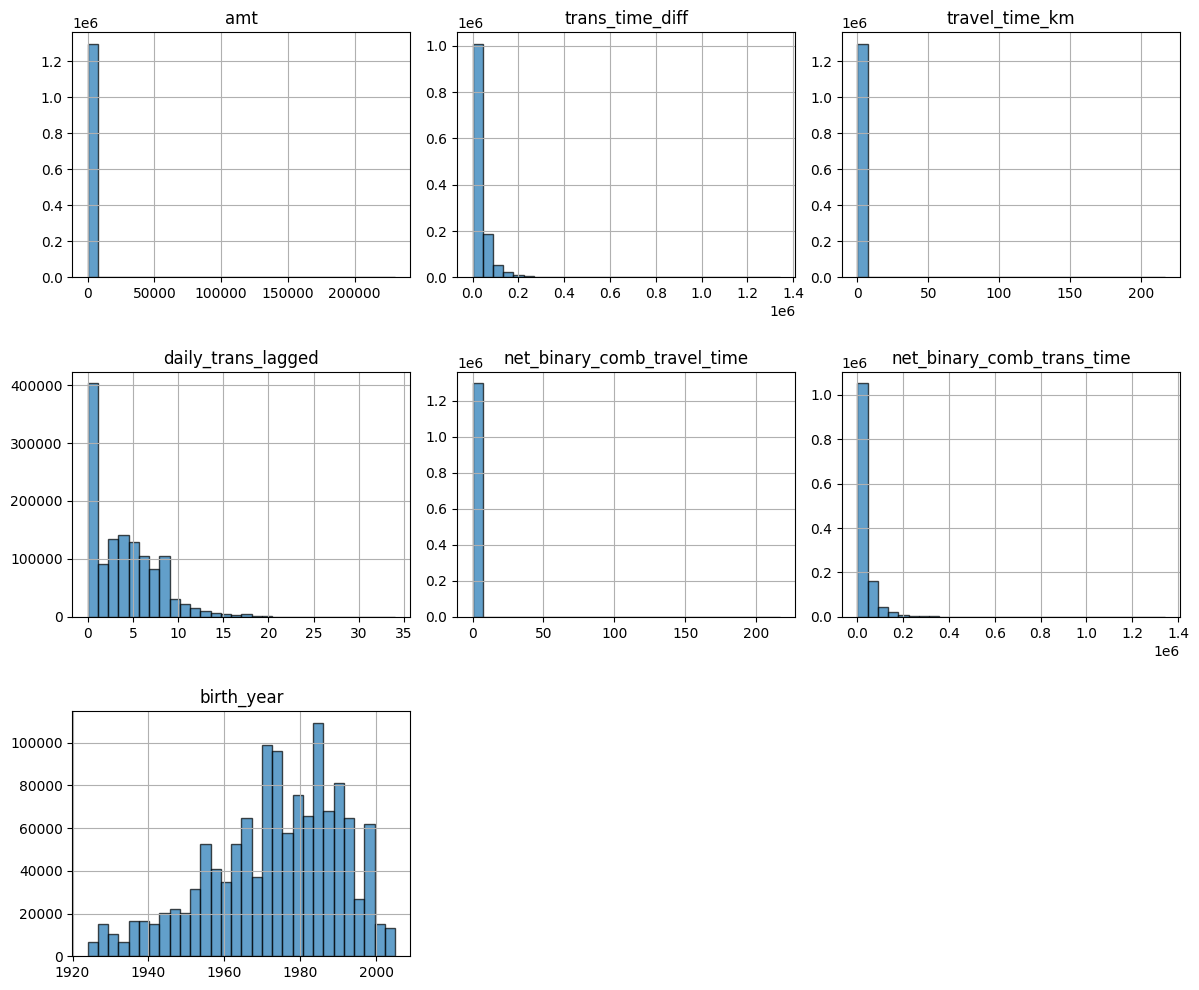

In [9]:
# 5. Distribution of all numeric features (histograms)
ax5 = plt.subplot(3, 2, 5)

# Select specific columns
selected_cols = ['amt',
 'trans_time_diff',
 'travel_time_km',
 'daily_trans_lagged',
 'net_binary_comb_travel_time',
 'net_binary_comb_trans_time',
 'birth_year']

# Plot histograms
fig = plt.gcf()
fig.set_size_inches(12, 10)  # Increased from default size
X[selected_cols].hist(ax=ax5, bins=30, alpha=0.7, edgecolor='black')
ax5.set_title('Numeric Features Distribution', fontsize=6)
plt.tight_layout()
#plt.close()

Since the plots are scaled nasty and does not lead to visualy analyze them, cutting the outliers is conducted for the plot. Not deleting them in the data for the models:

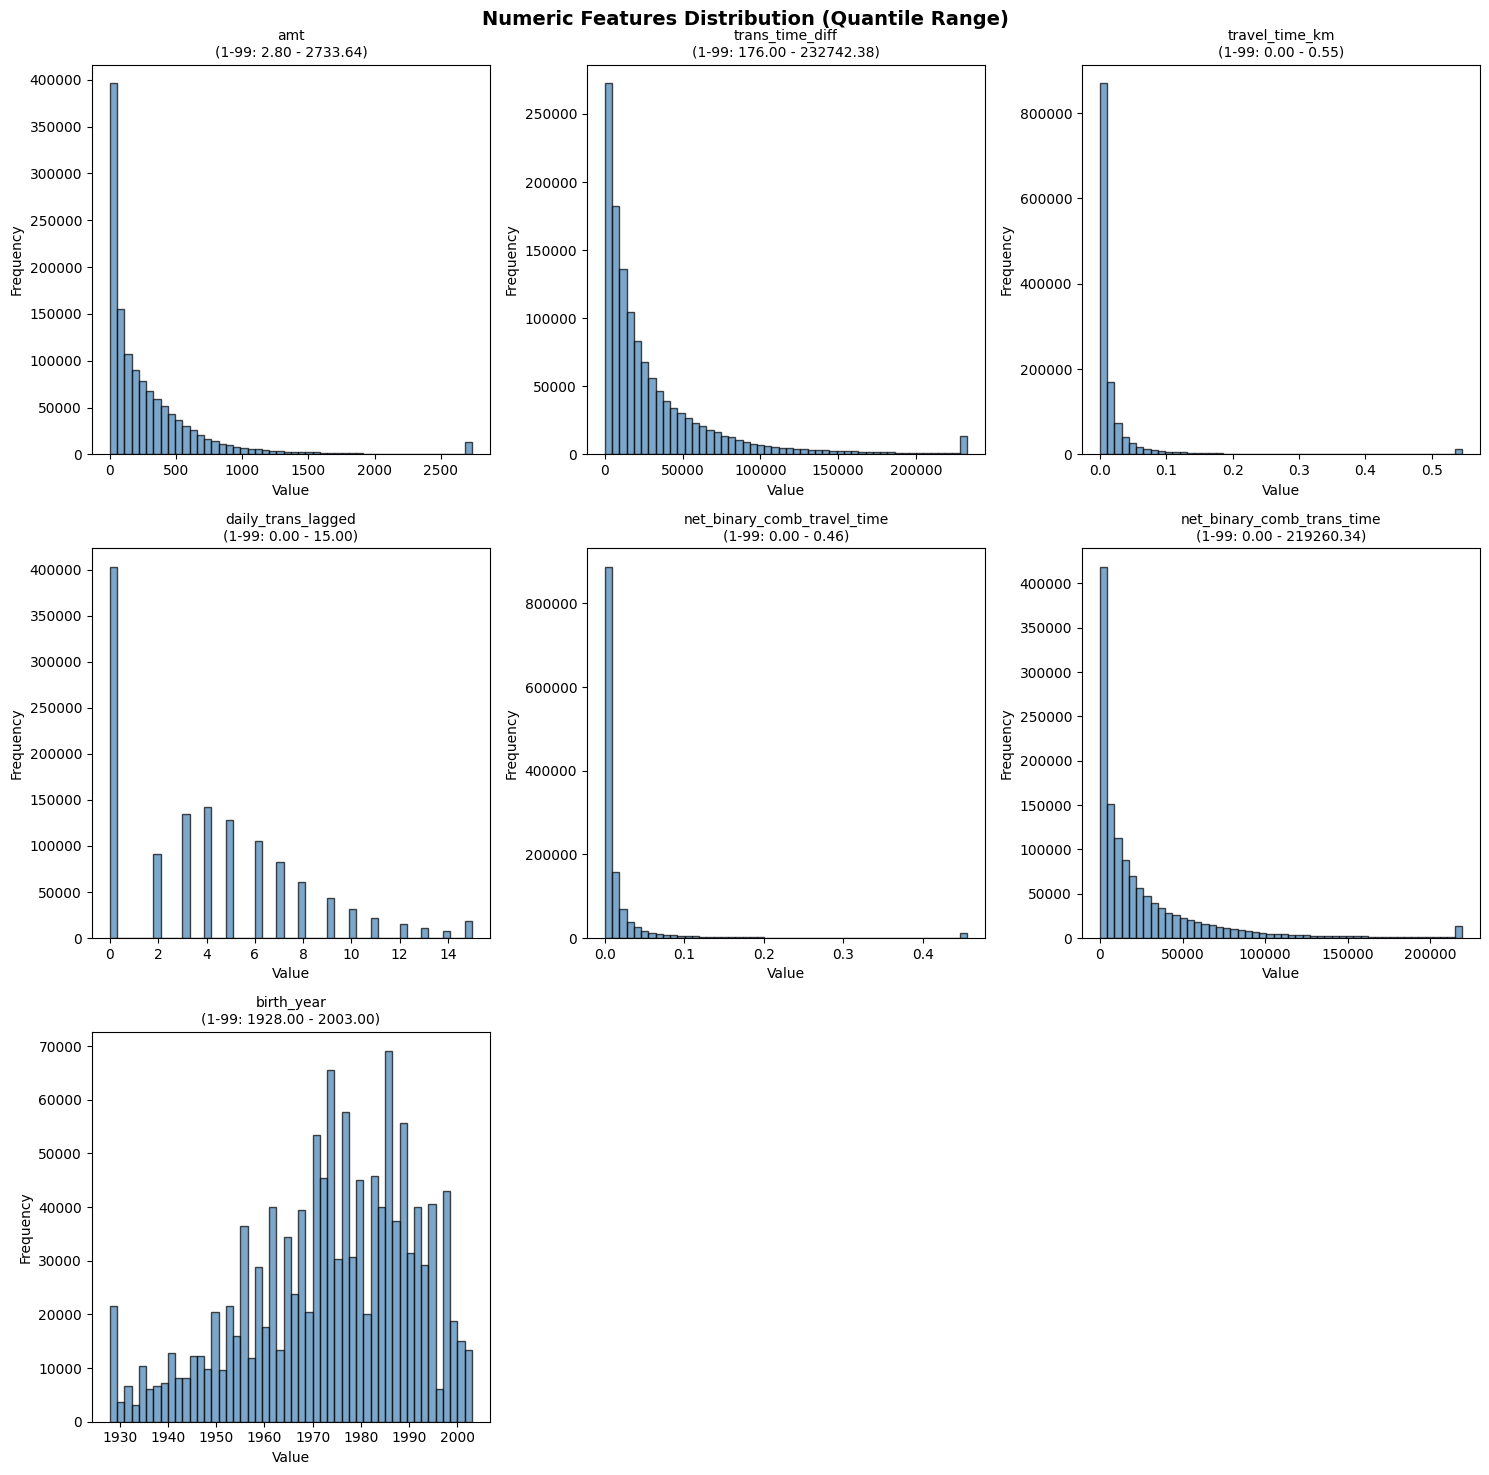

In [10]:
# 5. Distribution of numeric features without outliers 
n_cols = len(selected_cols)
n_plot_cols = 3  
n_plot_rows = (n_cols + n_plot_cols - 1) // n_plot_cols  # Ceiling division

fig, axes = plt.subplots(n_plot_rows, n_plot_cols, figsize=(15, 5*n_plot_rows))
axes = axes.flatten() if n_plot_rows > 1 else [axes]

for i, col in enumerate(selected_cols):
    # 1st and 99th percentile to make distribution more visible 
    lower = X[col].quantile(0.01)
    upper = X[col].quantile(0.99)
    X_clipped = X[col].clip(lower, upper)
    
    axes[i].hist(X_clipped, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}\n(1-99: {lower:.2f} - {upper:.2f})', fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

for i in range(len(selected_cols), len(axes)): # empty plots needs here to be removed
    axes[i].remove()

plt.suptitle('Numeric Features Distribution (Quantile Range)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

Plotting the correlation matrix of the variables lead to the following:

In [11]:
import pandas as pd

correlation_matrix = pd.DataFrame({
    'amt': X['amt'],
    'trans_time_diff': X['trans_time_diff'],
    'travel_time_km': X['travel_time_km'],
    'daily_trans_lagged': X['daily_trans_lagged'],
    'net_binary_comb_travel_time': X['net_binary_comb_travel_time'],
    'net_binary_comb_trans_time': X['net_binary_comb_trans_time'],
    'birth_year': X['birth_year']
}).corr()
correlation_matrix

,amt,trans_time_diff,travel_time_km,daily_trans_lagged,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year
amt,1.000000,-0.002203,0.001507,-0.002832,-0.000503,-0.004556,0.008208
trans_time_diff,-0.002203,1.000000,-0.032031,-0.464295,-0.029294,0.892473,-0.097986
travel_time_km,0.001507,-0.032031,1.000000,0.043200,0.914238,-0.028308,0.010218
daily_trans_lagged,-0.002832,-0.464295,0.043200,1.000000,0.038582,-0.401904,0.167689
net_binary_comb_travel_time,-0.000503,-0.029294,0.914238,0.038582,1.000000,-0.025573,0.008396
net_binary_comb_trans_time,-0.004556,0.892473,-0.028308,-0.401904,-0.025573,1.000000,-0.102135
birth_year,0.008208,-0.097986,0.010218,0.167689,0.008396,-0.102135,1.000000


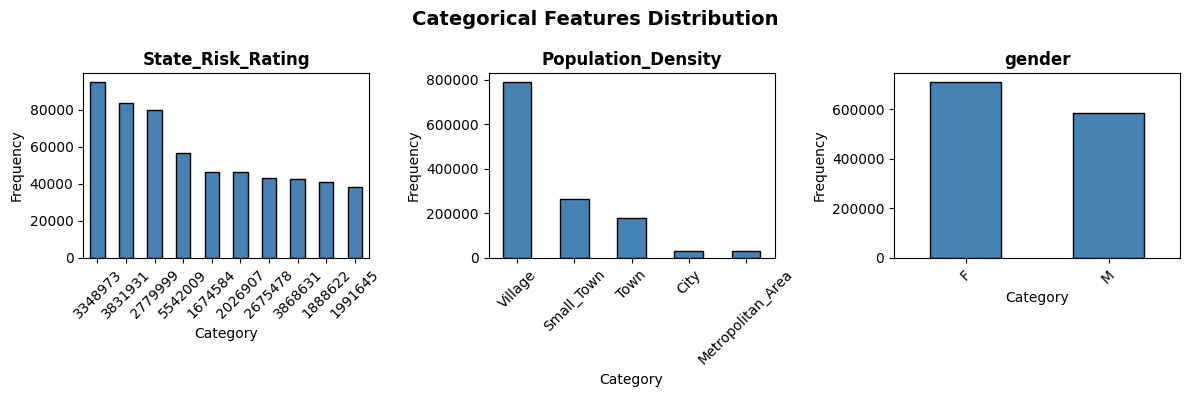

In [12]:
# Categorical variables visualization (separate plots)
categorical_cols = ['State_Risk_Rating', 'Population_Density','gender']

fig, axes = plt.subplots(1, len(categorical_cols), figsize=(12, 4))

for i, col in enumerate(categorical_cols):
    X[col].value_counts().head(10).plot(kind='bar', ax=axes[i], color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Category')
    axes[i].set_ylabel('Frequency')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Categorical Features Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Preprocessing for LightGBM ->  XGBoost & RandomForest

In comparison to the algorithm of the Machine Learning course provided by UWM, in this tree based pipeline a more simplified preprocessing is conducted. First of all, since there are no missings in the dataset (Which is not totally unrealistic for those personal data and transaction data, considering the high regulation of data lineage and data quality in banks, their credit card transaction data is originated in their banking systems. It is more likelly that the personal data is not actual, which happens often, but is not easy to measure or consider.) the imputation step is skipped.
The scaling of numeric variables is for tree based alorithms skipped as well, since the splits are based on value comparisons.


In [13]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder #, OneHotEncoder not used in this version

X['gender'] = X['gender'].map({'Male': 0, 'Female': 1})

# Preprocessing with encoding 
preprocessor = ColumnTransformer([
    ('state_risk', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['State_Risk_Rating']),
    ('population', OrdinalEncoder(categories=[['Village', 'Small_Town', 'Town', 'City', 'Metropolitan_Area']], handle_unknown='use_encoded_value', unknown_value=-1), ['Population_Density']),
    #('generation', OrdinalEncoder(categories=[['War_generation', 'Boomer', 'Gen X', 'Millennials', 'Gen Z']], handle_unknown='use_encoded_value', unknown_value=-1), ['generation']),
    ('pass', 'passthrough', [
        'amt', 'trans_time_diff', 
        'travel_time_km', 'daily_trans_lagged', 
        'net_binary',  'birth_year',
        'net_binary_comb_trans_time','net_binary_comb_travel_time','gender'
    ]),  # unchanged variables
]) 

## Light GBM as feature selection

To filtering useless features and also checking the hirarchy of our highly multicollinearated features, to make our final decision about the model input features, LightGBM is used. 
This approach follows the publication by S. Shi et al. (2025, p. 3): "We apply LightGBM as the tool to conduct an #automatic feature selection process.LightGBM, developed by Microsoft in 2017, is a tree-based gradient-boosting framework. Its most extraordinary advantages are efficiency and distributed computing. There are built-in functions that can calculate feature importance scores automatically and visualize the sortation of importance."

In [14]:
import lightgbm as lgb
from sklearn.pipeline import Pipeline
# pipeline with LightGBM (Non Linear relationships)
pipeline_LGB = Pipeline([
    ('preprocessor', preprocessor),
    ('model', lgb.LGBMClassifier(
        n_estimators=100,
        max_depth=5,
        learning_rate=0.1,
        random_state=42,
        class_weight='balanced'
    ))
])

Fitting now the LightGBM Pipeline and printing the feature hirarchy.

In [15]:
pipeline_LGB.fit(X, y)

feature_importance = pipeline_LGB.named_steps['model'].feature_importances_

importance_df = pd.DataFrame({
    'feature': pipeline_LGB.named_steps['preprocessor'].get_feature_names_out(),
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print(importance_df.head(20))

[LightGBM] [Info] Number of positive: 7506, number of negative: 1289169
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005900 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1445
[LightGBM] [Info] Number of data points in the train set: 1296675, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

The result of LGBM leads to the following list of features: Amount as the most relevant variable in fraud prediction, which is in line with (Dornadula & Geetha, 2019) focusing mainly on transaction amount related features for prediction. Gender is excluded, which would be criticall from an ethical viewpoint as well.

### Selection of Features

In [16]:
# Feature Update.
relevant_Feat=['amt',
    'daily_trans_lagged',
    #'dist_client_merchant', # ERROR perfect predictability
    #'trans_time_diff', OUT!
    'travel_time_km',
    #'daily_trans_lagged', OUT!
    'net_binary_comb_travel_time', # Error 
    'net_binary_comb_trans_time', # error predictability
    #'Amount_Outlier_bin_comb_amt',
    'birth_year',
    #'weekly_transactions',
    #'net_binary', OUT!
    #'Amount_Outlier_bin', OUT!
    'State_Risk_Rating',
    #'generation', OUT!
    'Population_Density']
x=X[relevant_Feat]
x

,amt,daily_trans_lagged,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year,State_Risk_Rating,Population_Density
0,38.731176,0,0.000000,0.000000,0.0,1986,2353556,Village
1,205.568402,0,0.003126,0.003126,71862.0,1986,2353556,Village
2,86.873989,4,0.661115,0.661115,159.0,1986,2353556,Village
3,78.630423,4,0.006367,0.006367,13838.0,1986,2353556,Village
4,65.831735,4,0.068047,0.068047,1952.0,1986,2353556,Village
...,...,...,...,...,...,...,...,...
1296670,391.859479,4,0.002344,0.002344,30740.0,1956,2675478,Village
1296671,541.232555,0,0.003872,0.003872,12962.0,1956,2675478,Village
1296672,1354.000769,4,0.012379,0.000000,0.0,1956,2675478,Village
1296673,15.224696,4,0.003213,0.003213,18989.0,1956,2675478,Village


## XGBoost Pipeline application

The following XGBoost Pipeline is done as following (And then conducted a second time via a Random Forest Pipeline)
- 1. Step: XGBoost Pipeline definition 
- 2. Step: Random hyperparameter construction for XGB
- 3. Step: Use randomized hyperparameters in the XGBoost pipeline, including Cross-Validation
- 4. Step: Fit XGBoost via the defined pipeline and hyperparameters, then export the best parameter scores
- 5. Step: Use the best hyperparameters for the final XGBoost model

In [18]:
import xgboost as xgb
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform
from sklearn.metrics import roc_auc_score, accuracy_score,  precision_score,  recall_score, f1_score, confusion_matrix, classification_report
# Update in the preprocessor:
relevant_feat_pass = relevant_Feat.copy()
relevant_feat_pass.remove('State_Risk_Rating')
relevant_feat_pass.remove('Population_Density')

preprocessor = ColumnTransformer([
    ('state_risk', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), ['State_Risk_Rating']),
    ('population', OrdinalEncoder(categories=[['Village', 'Small_Town', 'Town', 'City', 'Metropolitan_Area']], handle_unknown='use_encoded_value', unknown_value=-1), ['Population_Density']),
    #('generation', OrdinalEncoder(categories=[['War_generation', 'Boomer', 'Gen X', 'Millennials', 'Gen Z']], handle_unknown='use_encoded_value', unknown_value=-1), ['generation']),
    ('pass', 'passthrough',relevant_feat_pass),  # unchanged variables
]) 

In [19]:
## XGBoost as Model
pipeline_xgboost = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', xgb.XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ))
])

pipeline_xgboost

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state_risk', ...), ('population', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

In [20]:
hiperparam_distributions = {
    'classifier__n_estimators': randint(50, 100),           # Number of trees
    'classifier__max_depth': randint(3, 10),                # Tree depth - pretty high with 8
    'classifier__learning_rate': uniform(0.01, 0.3),        # Step size shrinkage - learning rate seems about 5% reasonable
    'classifier__subsample': uniform(0.6, 0.4),             # Row sampling
    'classifier__colsample_bytree': uniform(0.6, 0.4),      # Column sampling
    'classifier__min_child_weight': randint(1, 10),         # Min instances in leaf
    'classifier__gamma': uniform(0, 0.5),                   # Min loss reduction
    'classifier__reg_alpha': uniform(0, 1),                 # L1 regularization
    'classifier__reg_lambda': uniform(0.5, 1.5)             # L2 regularization
}

In [21]:
randomized_search_xgb = RandomizedSearchCV(
    pipeline_xgboost,
    hiperparam_distributions,
    n_iter=10,
    cv=5, # cross validation 5 fold
    scoring={'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'recall':'recall',
        'f1':'f1'},
        #'precision': 'precision'}, #precision is useless without testing on testset 
    refit='recall',                 
    random_state=42,
    n_jobs=-1,                        #parallel processing on mkl optinmized Intel 
    verbose=1 
)
randomized_search_xgb

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__colsample_bytree': <scipy.stats....x7a7d3005d390>, 'classifier__gamma': <scipy.stats....x7a7d3005e8d0>, 'classifier__learning_rate': <scipy.stats....x7a7d3015da90>, 'classifier__max_depth': <scipy.stats....x7a7d2b55e150>, ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. T

In [22]:
randomized_search_xgb.fit(x, y)
print("Best params:", randomized_search_xgb.best_params_)
print("Best score:", randomized_search_xgb.best_score_)

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'classifier__colsample_bytree': np.float64(0.9579309401710595), 'classifier__gamma': np.float64(0.29894998940554257), 'classifier__learning_rate': np.float64(0.28656227050693506), 'classifier__max_depth': 8, 'classifier__min_child_weight': 7, 'classifier__n_estimators': 89, 'classifier__reg_alpha': np.float64(0.8445338486781514), 'classifier__reg_lambda': np.float64(1.6209801652060714), 'classifier__subsample': np.float64(0.815876852955632)}
Best score: 0.22448514128619093


In [23]:
from xgboost import XGBClassifier
best_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('classifier', XGBClassifier(
        n_estimators = randomized_search_xgb.best_params_['classifier__n_estimators'],
        max_depth = randomized_search_xgb.best_params_['classifier__max_depth'],
        learning_rate = randomized_search_xgb.best_params_['classifier__learning_rate'],
        subsample = randomized_search_xgb.best_params_['classifier__subsample'],
        colsample_bytree = randomized_search_xgb.best_params_['classifier__colsample_bytree'],
        min_child_weight = randomized_search_xgb.best_params_['classifier__min_child_weight'],
        gamma = randomized_search_xgb.best_params_['classifier__gamma'],
        reg_alpha  = randomized_search_xgb.best_params_['classifier__reg_alpha'],
        reg_lambda = randomized_search_xgb.best_params_['classifier__reg_lambda'],
        random_state=42,  
        eval_metric='logloss'  
    ))
])

In [24]:
X_test = cc_test[relevant_Feat].to_pandas() 
y_test = cc_test['is_fraud'].to_pandas()
X_test

,amt,daily_trans_lagged,travel_time_km,net_binary_comb_travel_time,net_binary_comb_trans_time,birth_year,State_Risk_Rating,Population_Density
0,869.349761,0,0.000000,0.000000,0.0,1986,2353556,Village
1,240.405621,2,0.007045,0.007045,11994.0,1986,2353556,Village
2,224.815967,0,0.003757,0.003757,55977.0,1986,2353556,Village
3,490.272295,2,0.002136,0.002136,27238.0,1986,2353556,Village
4,927.203388,0,0.000995,0.000995,75383.0,1986,2353556,Village
...,...,...,...,...,...,...,...,...
555714,532.528316,0,0.013673,0.013673,8077.0,1956,2675478,Village
555715,28.637996,5,0.008705,0.000000,0.0,1956,2675478,Village
555716,334.321254,5,0.003377,0.003377,21729.0,1956,2675478,Village
555717,200.734841,5,1.083131,1.083131,101.0,1956,2675478,Village


In [25]:
threshold = 0.25 # unbalanced data therefore lower threshold, trial and error lead to 0.25

In [26]:
# Predict on test set
best_pipeline.fit(x, y) 
y_pred_test = best_pipeline.predict_proba(X_test)[:, 1]
y_pred_class = (y_pred_test >= threshold).astype(int)

# performance metrics
auc_test = roc_auc_score(y_test, y_pred_test)
accuracy_test = accuracy_score(y_test, y_pred_class)
# better metrics for imbalanced data
precision = precision_score(y_test, y_pred_class)
recall = recall_score(y_test, y_pred_class)
f1 = f1_score(y_test, y_pred_class)

Printing the XGBoost model results

In [27]:
print(f"Best XGBoost Model results")
print(f'precision:{auc_test} accuracy test: {accuracy_test}')
print(f'precision:{precision} recall: {recall}  f1: {f1}')


Best XGBoost Model results
precision:0.8673657702994341 accuracy test: 0.9951108383913453
precision:0.3418141592920354 recall: 0.2881118881118881  f1: 0.31267391854287885


## RandomForest as challenger model

Same procedure but via RandomForest as validity check and performance benchmark.

1. Step Random Forest Pipeline definition. 
    - preprocessor (as before) & classifier set to RandomForest (RF)

In [28]:
from sklearn.ensemble import RandomForestClassifier

pipeline_RF = Pipeline([
    ('preprocessor', preprocessor), 
    ('classifier', RandomForestClassifier(
        random_state=42
    ))
])
pipeline_RF

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('state_risk', ...), ('population', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the d

2. Step: Random hyperparameter construction for RF

In [29]:

hiperparam_distributions_RF = {
    'classifier__n_estimators': randint(10, 65),           # Number of trees
    'classifier__max_depth': randint(3, 10),                # Tree depth
    'classifier__min_samples_split': randint(2, 20),        # Min samples to split a node
    'classifier__min_samples_leaf': randint(1, 10),         # Min samples in leaf node
    'classifier__max_features': ['sqrt', 'log2', None],     # Number of features to consider
    'classifier__bootstrap': [True, False],                 # Bootstrap samples or not
    'classifier__criterion': ['gini', 'entropy']            # Split quality metric
}
hiperparam_distributions_RF

{'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7a7d31917b50>,
 'classifier__max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7a7bac32d890>,
 'classifier__min_samples_split': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7a7d2b9ba5d0>,
 'classifier__min_samples_leaf': <scipy.stats._distn_infrastructure.rv_discrete_frozen at 0x7a7d32163450>,
 'classifier__max_features': ['sqrt', 'log2', None],
 'classifier__bootstrap': [True, False],
 'classifier__criterion': ['gini', 'entropy']}

3. Step usage of randomized hyperparameters in the RandomForest pipeline including Cross Validation.

In [30]:
randomized_search_rf = RandomizedSearchCV(
    pipeline_RF,                       # Changed for pipeline_RF
    hiperparam_distributions_RF,       # Change for RF 
    n_iter=10,                         # from here on, same to XGBoost
    cv=5,
    scoring={
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'recall': 'recall',
        'f1': 'f1'
    },
    refit='recall',                 # Optimize for recall
    random_state=42,
    n_jobs=-1,                      #parallel processing on mkl optinmized Intel
    verbose=1
)
randomized_search_rf

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'classifier__bootstrap': [True, False], 'classifier__criterion': ['gini', 'entropy'], 'classifier__max_depth': <scipy.stats....x7a7bac32d890>, 'classifier__max_features': ['sqrt', 'log2', ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",10
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.","{'accuracy': 'accuracy', 'f1': 'f1', 'recall': 'recall', 'roc_auc': 'roc_auc'}"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'recall'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffl

4. Step fitting RandomForest via defined Pipeline and Hyperparameter and exporting best parameter scores.

In [31]:
randomized_search_rf.fit(x, y)
print("Best params:", randomized_search_rf.best_params_)
print("Best score:", randomized_search_rf.best_score_)


Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best params: {'classifier__bootstrap': True, 'classifier__criterion': 'entropy', 'classifier__max_depth': 7, 'classifier__max_features': None, 'classifier__min_samples_leaf': 8, 'classifier__min_samples_split': 8, 'classifier__n_estimators': 28}
Best score: 0.15440917772528034


5. Step using the best hyperparameter for the RF.

In [32]:
RF_best_pipeline = Pipeline([
    ('preprocessor', preprocessor),  
    ('classifier', RandomForestClassifier(
        n_estimators = randomized_search_rf.best_params_['classifier__n_estimators'],
        max_depth = randomized_search_rf.best_params_['classifier__max_depth'],
        min_samples_split = randomized_search_rf.best_params_['classifier__min_samples_split'],
        min_samples_leaf = randomized_search_rf.best_params_['classifier__min_samples_leaf'],
        max_features = randomized_search_rf.best_params_['classifier__max_features'],
        bootstrap = randomized_search_rf.best_params_['classifier__bootstrap'],
        criterion = randomized_search_rf.best_params_['classifier__criterion'],
        random_state=42
    ))
])

In [33]:
# Predict on test set
RF_best_pipeline.fit(x, y)  #Here RF_best_pipeline (instead XGboost)
y_pred_test = RF_best_pipeline.predict_proba(X_test)[:, 1] #Here RF_best_pipeline (instead XGboost)
y_pred_class = (y_pred_test >= threshold).astype(int)

auc_test_RF = roc_auc_score(y_test, y_pred_test)
accuracy_test_RF = accuracy_score(y_test, y_pred_class)
#  metrics for imbalanced data
precision_RF = precision_score(y_test, y_pred_class)
recall_RF = recall_score(y_test, y_pred_class)
f1_RF = f1_score(y_test, y_pred_class)


Printing the RandomForest-Results

In [34]:
print(f"Best RandomForest Model ")
print(f'precision:{auc_test_RF} accuracy test: {accuracy_test_RF}')
print(f'precision:{precision_RF} recall: {recall_RF}  f1: {f1_RF}')


Best RandomForest Model 
precision:0.8904208766794438 accuracy test: 0.9954617351575167
precision:0.3904706565950029 recall: 0.3132867132867133  f1: 0.3476461458872219


## Analysis.

The metrics are analysed as following:
- AUC	How the model separates fraud against correct transactions (With the value of 1 ideally and 0.5 as random guess).
- Accuracy	The % of the total predictions that are correctly identified as fraud & legit.
- Precision	of transactions flagged as fraud in that, how many were actually fraud.
- Recall	Of fraud cases, how many did the model catch. This is chosen as our main criterium. Since the damage of fraud, which is not detected got the highest priority our models aim to get the highest recall.
- F1-Score	Harmonic mean of precision & recall balancing. 

Analysed comparison.
- Reminding that we got highly inbalanced data with a low amount of fraud data, the high ~99.5% accuracy,  is misleading, because a model could simply predict non_fraud for everything and achieve a really high score. Both models got high values in accuracy.
- XGBoost catches only ~29% of actual fraud cases. RandomForest catches some more of ~31% of fraud cases. A high number of around 70% fraud, is still undetected (False Negatives).
- Precision shows, that there is a lot of flagged fraud, and therefore above 60% are false alarms (False Positives).


The RandomForest results in better performance. For validation it would be interested to include another pipeline with LSVM, since it requires more steps considering outlier treatment via scaling considerations about relationship between variables including the issue of multicollinearity it was not included anymore.

## Enhancement of the Algorithm and critically view on the Project

A criticall view of the project directly leads to the discussion if the synthetic data is adequately providing any insides for credit card fraud detection. Unfortunately, since it is only minor information about the data on Hugging face available, a decent projection of original data relations in a fraud dataset is not for sure. As it already in earlier attempts occured, there are variables used in constructing the fraud marker. If there is eneough noise included or that the dataset realistically copies the relationship between fraud and their credit card data is not validated. 
Despite the main question of the dataset validity, the length of the dataset and included variables could be another criticall circumstance in this project. More variables (User credit card ratings, technical data like physicall or online card usage etc) could dramatically enhance the prediction.
The project used the limited available variables and constructed some features, which are at least worth testing and could provide some insights on other datasets (mostly transaction time and distance relations). It could be further enhanced if more about the credit card transaction amount is used in features. For example outlier for each transaction time stamp (over all credit card user) could be a valid feature, which does not invalidate the constraint of future information for the specific row. Another point could be using retrospective transaction data, for calculating outliers by each credit card (rolling windows).
The project only used a small range of randomly chosen hyperparameters due to computational limitations further analysis could even boost the rather low performance of the models.
This project only considered Treebased models, neuronal nets (VAE), logistic regressions, or LSVM were used in academia and could be worth implementing as comparison.

## Bibliography 

Bin Sulaiman, R., Schetinin, V., & Sant, P. (2022). Review of Machine Learning Approach on Credit Card Fraud Detection. Human-Centric Intelligent Systems, 2(1–2), 55–68. https://doi.org/10.1007/s44230-022-00004-0
Dornadula, V. N., & Geetha, S. (2019). Credit Card Fraud Detection using Machine Learning Algorithms. Procedia Computer Science, 165, 631–641. https://doi.org/10.1016/j.procs.2020.01.057
Peng, Y., Xu, J., Ma, L., & Wang, J. (2021). PREDICTION OF HYPERTENSION RISKS WITH FEATURE SELECTION AND XGBOOST. Journal of Mechanics in Medicine and Biology, 21(05), 2140028. https://doi.org/10.1142/S0219519421400285
Shi, S., Luo, W., & Pau, G. (2025). An attention-based balanced variational autoencoder method for credit card fraud detection. Applied Soft Computing, 177, 113190. https://doi.org/10.1016/j.asoc.2025.113190
Tiwari, P., Mehta, S., Sakhuja, N., Kumar, J., & Singh, A. K. (2021). Credit Card Fraud Detection using Machine Learning: A Study (arXiv:2108.10005). arXiv. https://doi.org/10.48550/arXiv.2108.10005
